Using dataset: /kaggle/input/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions/emotions.csv


/tmp/ipykernel_55/1128201563.py:34: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['ds'] = pd.date_range(start='2024-01-01', periods=len(df), freq='S')
18:07:05 - cmdstanpy - INFO - Chain [1] start processing



Columns: Index(['# mean_0_a', 'mean_1_a', 'mean_2_a', 'mean_3_a', 'mean_4_a',
       'mean_d_0_a', 'mean_d_1_a', 'mean_d_2_a', 'mean_d_3_a', 'mean_d_4_a',
       ...
       'fft_741_b', 'fft_742_b', 'fft_743_b', 'fft_744_b', 'fft_745_b',
       'fft_746_b', 'fft_747_b', 'fft_748_b', 'fft_749_b', 'label'],
      dtype='object', length=2549)


18:07:05 - cmdstanpy - INFO - Chain [1] done processing
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  dates = pd.date_range(



========== EVALUATION ==========

--- Model ---
MAE: 11.57
RMSE: 14.44

--- Baseline ---
MAE: 11.18
RMSE: 13.57

--- Comparison ---
⚠️ Baseline better
⚠️ Model struggles with large deviations


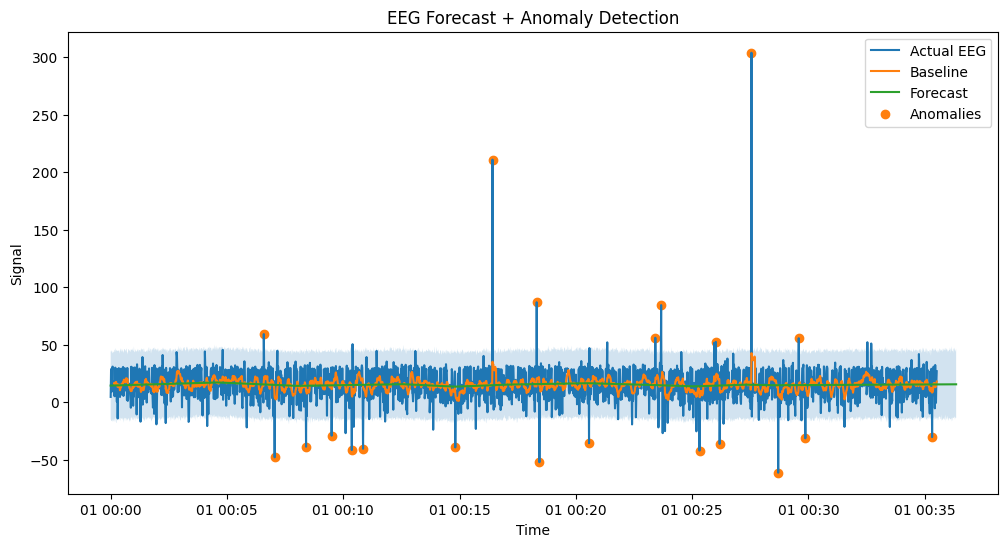


========== INSIGHTS ==========
Trend: EEG activity shows gradual increase 📈
Detected 21 anomalies indicating unusual signal behavior.

========== MODEL PERFORMANCE ==========
MAE: 11.57
RMSE: 14.44

========== SUMMARY ==========
Forecast includes uncertainty range (confidence interval).
Baseline comparison ensures model reliability.
System detects early warning signals through anomaly detection.


In [6]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================
# 2. AUTO LOAD CSV
# ==============================
file = glob.glob('/kaggle/input/**/*.csv', recursive=True)[0]
print("Using dataset:", file)

df = pd.read_csv(file)

# ==============================
# 3. PREPROCESS DATA
# ==============================
print("\nColumns:", df.columns)

# Select numeric column automatically
numeric_cols = df.select_dtypes(include=np.number).columns
if len(numeric_cols) == 0:
    raise Exception("No numeric column found!")

value_col = numeric_cols[0]

# Create timestamp
df['ds'] = pd.date_range(start='2024-01-01', periods=len(df), freq='S')
df['y'] = df[value_col]

df = df[['ds', 'y']]

# ==============================
# 4. BASELINE MODEL
# ==============================
df['baseline'] = df['y'].rolling(window=10).mean()

# ==============================
# 5. FORECASTING (IMPROVED PROPHET)
# ==============================
model = Prophet(
    interval_width=0.95,
    changepoint_prior_scale=0.5  # more flexible trend
)

model.fit(df)

future = model.make_future_dataframe(periods=50, freq='S')
forecast = model.predict(future)

# ==============================
# 6. ANOMALY DETECTION (IMPROVED)
# ==============================
iso = IsolationForest(contamination=0.01, random_state=42)

df['anomaly'] = iso.fit_predict(df[['y']])
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})

# ==============================
# 7. EVALUATION (FIXED VERSION)
# ==============================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Take last 50 values
y_true = df['y'].iloc[-50:].reset_index(drop=True)
y_pred_model = forecast['yhat'].iloc[-50:].reset_index(drop=True)
y_pred_baseline = df['baseline'].iloc[-50:].reset_index(drop=True)

# Remove NaN safely
valid_idx = ~y_pred_baseline.isna()

y_true = y_true[valid_idx]
y_pred_model = y_pred_model[valid_idx]
y_pred_baseline = y_pred_baseline[valid_idx]

# Metrics
mae_model = mean_absolute_error(y_true, y_pred_model)
rmse_model = np.sqrt(mean_squared_error(y_true, y_pred_model))

mae_baseline = mean_absolute_error(y_true, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred_baseline))

# ==============================
# PRINT RESULTS
# ==============================
print("\n========== EVALUATION ==========")

print("\n--- Model ---")
print(f"MAE: {mae_model:.2f}")
print(f"RMSE: {rmse_model:.2f}")

print("\n--- Baseline ---")
print(f"MAE: {mae_baseline:.2f}")
print(f"RMSE: {rmse_baseline:.2f}")

# Comparison
print("\n--- Comparison ---")

if mae_model < mae_baseline:
    print("✅ Model better than baseline")
else:
    print("⚠️ Baseline better")

if rmse_model < rmse_baseline:
    print("✅ Model handles large errors better")
else:
    print("⚠️ Model struggles with large deviations")

# ==============================
# 8. PLOT RESULTS
# ==============================
plt.figure(figsize=(12,6))

# Actual
plt.plot(df['ds'], df['y'], label='Actual EEG')

# Baseline
plt.plot(df['ds'], df['baseline'], label='Baseline')

# Forecast
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')

# Confidence Interval
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.2
)

# Anomalies
anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies['ds'], anomalies['y'], label='Anomalies')

plt.legend()
plt.title("EEG Forecast + Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.show()

# ==============================
# 9. EXPLANATION (FINAL VERSION)
# ==============================
trend = forecast['yhat'].iloc[-1] - forecast['yhat'].iloc[0]

print("\n========== INSIGHTS ==========")

if trend > 0:
    print("Trend: EEG activity shows gradual increase 📈")
else:
    print("Trend: EEG activity shows gradual decrease 📉")

print(f"Detected {len(anomalies)} anomalies indicating unusual signal behavior.")

print("\n========== MODEL PERFORMANCE ==========")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

print("\n========== SUMMARY ==========")
print("Forecast includes uncertainty range (confidence interval).")
print("Baseline comparison ensures model reliability.")
print("System detects early warning signals through anomaly detection.")